In [4]:
#Gabriel Machorro
#Partner's Name: Robert
#Links: https://www.kaggle.com/datasets/showmik121/smartphones-dataset-2026-1000-devices?resource=download
#https://www.kaggle.com/datasets/denkuznetz/housing-prices-regression

import xgboost as xgb
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

df = pd.read_csv("smartprix_smartphones_april_2026.csv")

print(f"Total samples: {len(df)}")
print(f"Number of features: {df.shape[1] - 1}")

print("\nFirst 5 rows:")
print(df.head())

# ============================================================================
# STEP 2: TARGET + FEATURES
# ============================================================================

target = "price_category"

X = df.drop(columns=[target])
y = df[target]

# Encode target labels (VERY IMPORTANT)
le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(np.unique(y))

print(f"\nClasses found: {le.classes_}")
print(f"Number of classes: {num_classes}")

# ============================================================================
# STEP 3: HANDLE CATEGORICAL FEATURES
# ============================================================================

# Identify categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"\nFinal feature count after encoding: {X.shape[1]}")

# ============================================================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ============================================================================
# STEP 5: TRAIN XGBOOST MODEL
# ============================================================================

model = xgb.XGBClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=num_classes,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

print("\nTraining model...")
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
print("Training complete!")

# ============================================================================
# STEP 6: PREDICTIONS
# ============================================================================

y_pred = model.predict(X_test)

# ============================================================================
# STEP 7: EVALUATION
# ============================================================================

acc = accuracy_score(y_test, y_pred)

print("\n================ RESULTS ================")
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Total samples: 997
Number of features: 25

First 5 rows:
  brand_name                     model price_category   price  spec_score  \
0    oneplus            OnePlus Nord 6        Premium   38999          81   
1    samsung  Samsung Galaxy S25 Ultra       Flagship  110000          89   
2       vivo               Vivo T5 Pro      Mid-Range   29999          72   
3    samsung     Samsung Galaxy S25 FE        Premium   50743          77   
4       vivo               Vivo T5x 5G      Mid-Range   18999          66   

   vfm_score      vfm_label  has_5G  has_NFC  has_IR  ...  \
0   0.906828  Average Value    True     True    True  ...   
1   0.658517  Average Value    True     True   False  ...   
2   1.522389     Value King    True    False    True  ...   
3   0.282124  Average Value    True     True   False  ...   
4   0.478615  Average Value    True    False    True  ...   

  battery_capacity(mAh) fast_charging(W)  charging_ratio  charging_speed_type  \
0                9000.0         

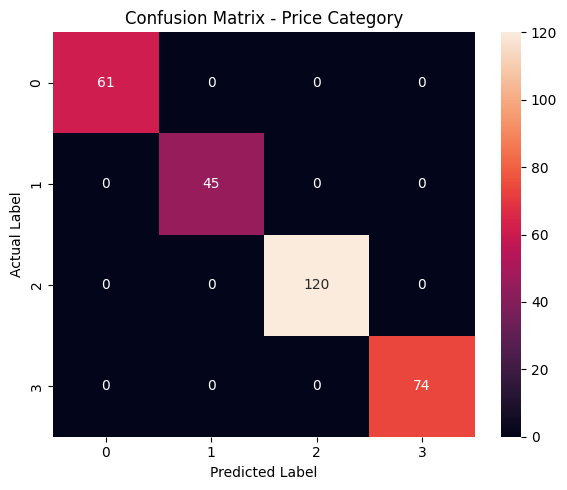

In [5]:
#Importing libraries needed for matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#Build confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Price Category")
plt.tight_layout()
plt.show()

In [ ]:
#Before training, the data was prepared by separating the target variable (price_category) from the input features and converting categorical
#information (such as brand and operating system) into a numerical format that the model can understand. The dataset was then split into training and
#testing portions to evaluate performance fairly. After training, the model’s predictions were assessed using accuracy metrics and a confusion matrix to
#understand how well it distinguishes between different price categories.

Saving real_estate_dataset.csv to real_estate_dataset (1).csv
Total samples: 500
Number of columns: 12

Column names:
  1. ID
  2. Square_Feet
  3. Num_Bedrooms
  4. Num_Bathrooms
  5. Num_Floors
  6. Year_Built
  7. Has_Garden
  8. Has_Pool
  9. Garage_Size
  10. Location_Score
  11. Distance_to_Center
  12. Price

First 5 rows of the dataset:
   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.0614

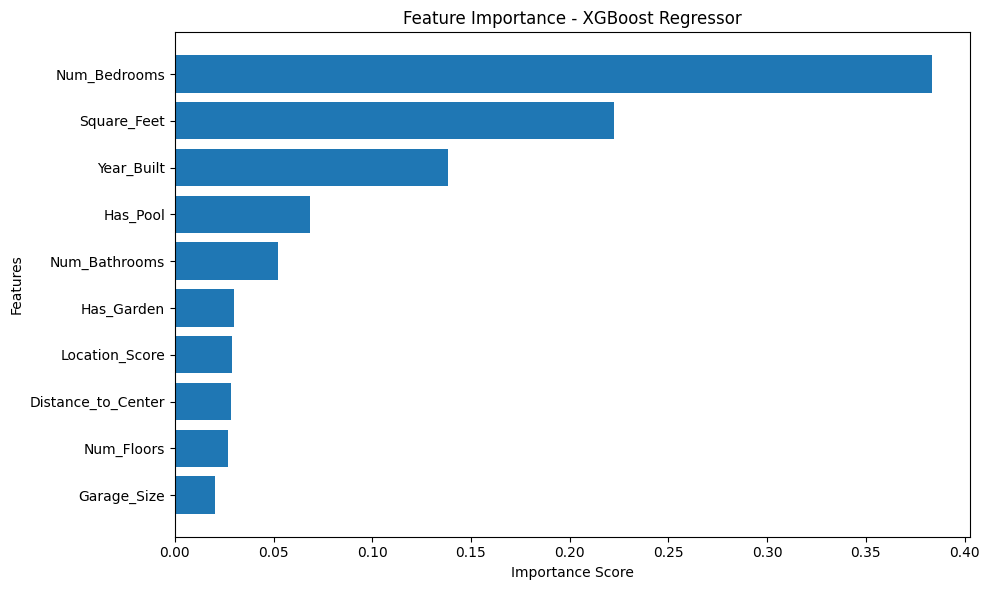

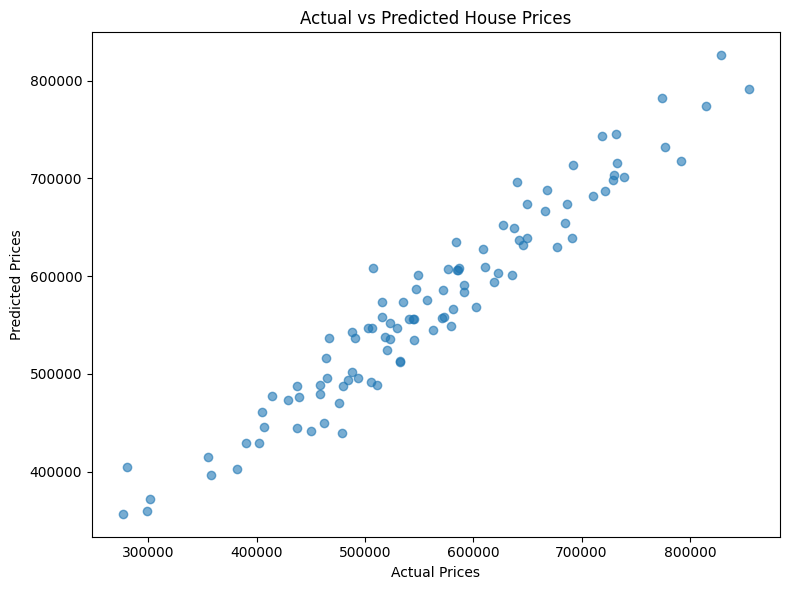


SAMPLE PREDICTIONS
    Actual Price  Predicted Price    Difference
0  591058.708950     583335.87500   7722.833950
1  667693.000276     688279.12500 -20586.124724
2  532377.580195     511733.09375  20644.486445
3  478489.299027     439183.90625  39305.392777
4  730197.480607     703985.37500  26212.105607
5  515544.254783     557999.12500 -42454.870217
6  354991.349233     414995.37500 -60004.025767
7  573486.145827     557923.81250  15562.333327
8  529467.599267     547176.37500 -17708.775733
9  739265.736526     701457.31250  37808.424026


In [7]:
# Import necessary libraries
import xgboost as xgb  # XGBoost library
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Regression metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: LOAD AND EXPLORE THE DATA
# ============================================================================

# Load the real estate dataset from CSV
# Make sure this CSV file is in the same folder as your Python file
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("real_estate_dataset.csv")

print(f"Total samples: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names:")
for i, name in enumerate(df.columns, 1):
    print(f"  {i}. {name}")

print(f"\nFirst 5 rows of the dataset:")
print(df.head())

# Define target variable
target_column = "Price"

print(f"\nTarget variable statistics (House Price):")
print(f"  Minimum: ${df[target_column].min():,.2f}")
print(f"  Maximum: ${df[target_column].max():,.2f}")
print(f"  Mean:    ${df[target_column].mean():,.2f}")
print(f"  Median:  ${df[target_column].median():,.2f}")

# ============================================================================
# STEP 2: PREPARE AND SIMPLIFY DATASET
# ============================================================================

# Drop ID column since it is just an identifier and not useful for prediction
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Separate features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]

# Use a smaller sample if dataset is large
# Here we use the full dataset if it has 5000 rows or fewer
np.random.seed(42)  # For reproducibility

if len(df) > 5000:
    sample_indices = np.random.choice(len(X), size=5000, replace=False)
    X_simplified = X.iloc[sample_indices]
    y_simplified = y.iloc[sample_indices]
else:
    X_simplified = X
    y_simplified = y

print(f"\nReduced dataset size: {len(X_simplified)} samples")
print(f"Number of features used: {X_simplified.shape[1]}")

# ============================================================================
# STEP 3: SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================================

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_simplified, y_simplified,
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# ============================================================================
# STEP 4: CREATE AND TRAIN THE XGBOOST REGRESSOR
# ============================================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST REGRESSOR")
print("=" * 70)

# Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    max_depth=4,                 # Maximum depth of trees
    n_estimators=100,            # Number of boosting rounds (trees)
    learning_rate=0.1,           # Step size for updating predictions
    objective='reg:squarederror',# Standard for regression
    random_state=42,             # For reproducibility
    subsample=0.8,               # Use 80% of data for each tree
    colsample_bytree=0.8         # Use 80% of features for each tree
)

print("Model parameters:")
print(f"  - Max tree depth: {model.max_depth}")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - Subsample ratio: {model.subsample}")

# Train the model
print("\nTraining in progress...")
model.fit(X_train, y_train, verbose=False)
print("✓ Training complete!")

# ============================================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================================

# Predict on both training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ============================================================================
# STEP 6: EVALUATE THE MODEL
# ============================================================================

print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTraining Set Performance:")
print(f"  RMSE: ${train_rmse:,.2f}")
print(f"  MAE:  ${train_mae:,.2f}")
print(f"  R²:   {train_r2:.4f}")

print("\nTesting Set Performance:")
print(f"  RMSE: ${test_rmse:,.2f}")
print(f"  MAE:  ${test_mae:,.2f}")
print(f"  R²:   {test_r2:.4f}")

# ============================================================================
# STEP 7: FEATURE IMPORTANCE
# ============================================================================

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

# ============================================================================
# STEP 8: VISUALIZE RESULTS
# ============================================================================

# Plot 1: Feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - XGBoost Regressor")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot 2: Actual vs Predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 9: SHOW SAMPLE PREDICTIONS
# ============================================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

results_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_test_pred,
    'Difference': y_test.values - y_test_pred
})

print(results_df.head(10))

In [ ]:
#Lab Report: This lab focused on building a machine learning model using XGBoost to estimate residential property prices based on key housing
#characteristics, with the goal of both predicting price accurately and identifying which features contribute most to value. The process began by
#loading and reviewing the dataset to understand its structure, then defining Price as the target variable while using features such as square footage,
#number of bedrooms and bathrooms, number of floors, year built, garage size, location score, distance to the city center, and amenities like gardens or
#pools as predictors. The dataset was cleaned by removing non-informational fields such as an ID column, then split into training and testing sets using
#an 80/20 approach to ensure the model could be evaluated on unseen data. An XGBoost regression model was trained using controlled parameters to balance
#learning accuracy with overfitting risk, and its performance was evaluated using RMSE, MAE, and R² metrics. The findings showed that the model was able
#to capture a strong portion of the variation in housing prices, with a relatively low prediction error and a solid R² value, indicating that the
#selected features were meaningful predictors of price. Feature importance results revealed that variables related to property size and location,
#particularly square footage and location score, had the greatest influence on predicted values, while factors like number of bedrooms or amenities
#such as a pool or garden had a smaller but still noticeable effect. The visualization comparing actual versus predicted prices showed a clear positive
#relationship, meaning the model’s predictions generally tracked real price patterns, although some variation remained for higher-priced properties,
#suggesting slight under- or over-estimation in extreme cases. Overall, the results demonstrate that the model is effective for estimating property
#values and that pricing is most strongly driven by core structural and location-based factors rather than secondary features. From a business
#perspective, these findings provide a practical foundation for pricing analysis, valuation support, and market comparison, while also offering insight
#into which property characteristics should be prioritized when assessing or marketing real estate.